# Customer Churn Prediction

## Loading the Dataset

The dataset is loaded using pandas for further analysis.

In [103]:
import pandas as pd

df=pd.read_csv('../data/Telco_customer_churn.csv')

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Data Understanding
In this step, we check the structure, columns and missing values in the dataset.

In [104]:
print(f'Shape : {df.shape}')
print(f'\nColumns: {df.columns}')
print(f'\nData Types: {df.dtypes}\n')
print(f'\nMissing Values: {df.isnull().sum()}')

Shape : (7043, 33)

Columns: Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

Data Types: CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months  

## Exploratory Data Analysis (EDA)
EDA is performed to understand patterns and relationships in the data.

### Churn Distribution
This plot shows the number of customers who stayed vs Churned

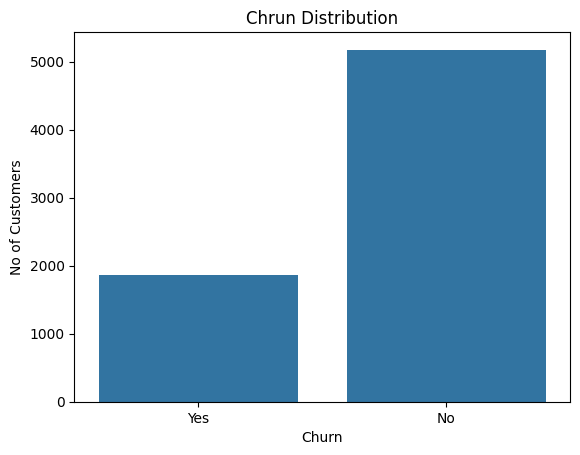

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn Label',data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('No of Customers')
plt.show()

### Tenure Distribution 
This show how long customers stay with the company.

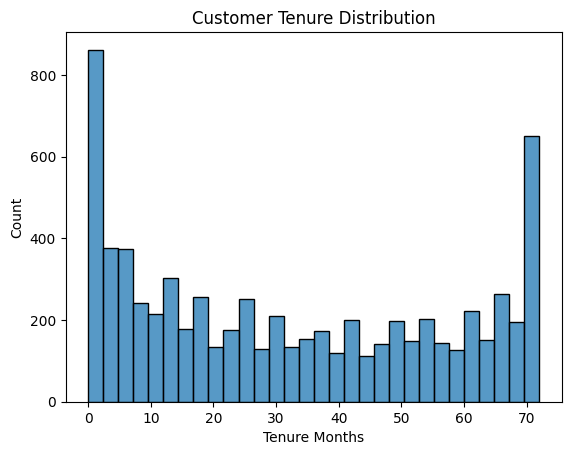

In [106]:
sns.histplot(df['Tenure Months'], bins=30)
plt.title('Customer Tenure Distribution')
plt.show()

### Contract Type vs Churn
This shows how contract type affects churn behavior.

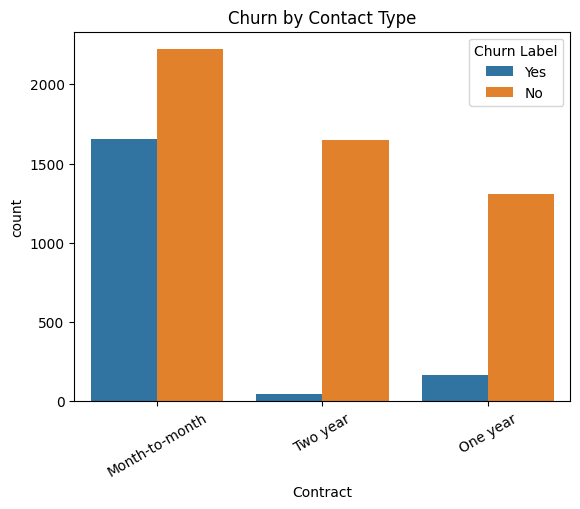

In [107]:
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xticks(rotation=30)
plt.title('Churn by Contact Type')
plt.show()

### Monthly Charges vs Churn
This helps analyze the impact of billing on churn.

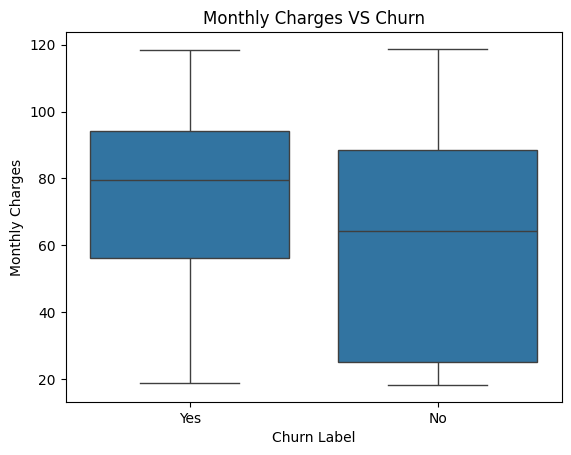

In [108]:
sns.boxplot(x='Churn Label',y='Monthly Charges',data=df)
plt.title('Monthly Charges VS Churn')
plt.show()

## Data Cleaning
Data Cleaning is performed to handle missing values and remove unnecessary columns.

In [110]:
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')
df=df.dropna(subset=['Total Charges'])

In [109]:
df=df.drop(['CustomerID', 'Count', 'Country', 'State', 'City', 'CLTV', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason'], axis=1)

## Feature Engineering
Categorical variables are converted into numerical format and numerical features are scaled.

In [111]:
df=pd.get_dummies(df, drop_first=True)

## Model Building 
A Random Forest Classifier is used to predict customer churn.

Numerical features are scaled to improve model performance and ensure all features are on the same scale.

In [112]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df[['Tenure Months', 'Monthly Charges', 'Total Charges']]=scaler.fit_transform(df[['Tenure Months', 'Monthly Charges', 'Total Charges']])

In [113]:
y= df['Churn Value']

X =df.drop('Churn Value',axis=1)

## Model evaluation
The model is evaluated using accuracy score and classification report.

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model=RandomForestClassifier()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Feature Importance
This step identifies the most important features influencing churn.

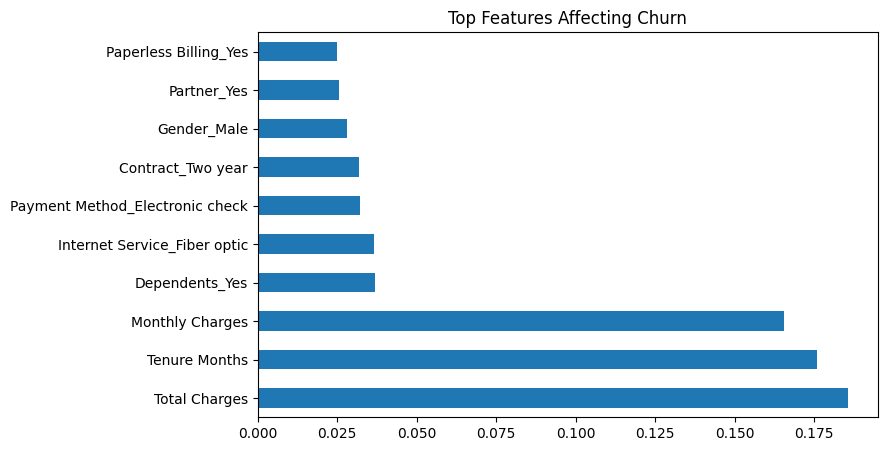

In [115]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh', figsize=(8,5))
plt.title('Top Features Affecting Churn')
plt.show()

### Key insights
- Customers with higher total charges and monthly charges are more like to churn
- Customers with shorter tenure tend to leave more frequently
- Fiber optic internet users show higher churn behavior
- Customer using electronic check payment method have higher churn rates
- customers with no dependents are more likely to churn 
- Long-term customers are more stable and less likely to leave